### Settings

In [1]:
COLAB = True
upload_weights = False
weights_to_upload = ['large']

In [2]:
import os
import shutil

In [3]:
def ignored_files(src, names):
    ignored = []
    for name in names:
        if ".pth" in name and all(size not in name for size in weights_to_upload):
            ignored.append(name) 
    return ignored


google_drive_path = "./drive/MyDrive/LLM_from_scratch/"

if COLAB:
    from google.colab import drive
    
    if os.path.exists("/content/drive"):
        print("Google Drive has already mounted.")
    else:        
        drive.mount('/content/drive')
        print("Google Drive is mounted")

    # ignore_pat = shutil.ignore_patterns('gpt2-large-*.pth') if not upload_weights else None
    shutil.copytree(google_drive_path, "./", ignore=ignored_files, dirs_exist_ok=True)
    print('Files are copied to a Colab server!')
else:
    print("Running locally, not mounting Google Drive.")

Mounted at /content/drive
Google Drive is mounted
Files are copied to a Colab server!


In [4]:
import torch
import torch.nn as nn
import tiktoken

import previous_chapters as prv

### 7.2 Preparing a dataset for supervised instruction fine-tuning

In [5]:
import json

In [6]:
json_file = 'instruction-data.json'

with open(json_file, 'r', encoding='utf-8') as f: 
    data = json.load(f)

In [7]:
data[:3]

[{'instruction': 'Evaluate the following phrase by transforming it into the spelling given.',
  'input': 'freind --> friend',
  'output': 'The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".'},
 {'instruction': 'Edit the following sentence for grammar.',
  'input': 'He go to the park every day.',
  'output': 'He goes to the park every day.'},
 {'instruction': 'Convert 45 kilometers to meters.',
  'input': '',
  'output': '45 kilometers is 45000 meters.'}]

In [8]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = (
    f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    return instruction_text + input_text

In [9]:
n = 999

model_input = format_input(data[n])
desired_response = f"\n\n### Response:\n{data[n]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [10]:
train_proportion = int(len(data) * 0.85)
test_proportion = int(len(data) * 0.1)
val_proportion = len(data) - train_proportion - test_proportion

train_data = data[:train_proportion]
test_data = data[train_proportion: train_proportion + test_proportion]
val_data = data[train_proportion + test_proportion:]

print(f'{len(train_data)=}')
print(f'{len(val_data)=}')
print(f'{len(test_data)=}')

len(train_data)=935
len(val_data)=55
len(test_data)=110


### 7.3 Organizing data into training batches

In [146]:
from torch.utils.data import Dataset, DataLoader

In [147]:
class InstructionDataset(Dataset):
    
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = self._format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            self.encoded_texts.append(
                tokenizer.encode(instruction_plus_input + response_text))
            
            
    def _format_input(self, entry):
        instruction_text = (
            f"Below is an instruction that describes a task. "
            f"Write a response that appropriately completes the request."
            f"\n\n### Instruction:\n{entry['instruction']}"
        )
        input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
        )
        return instruction_text + input_text
    
    def __getitem__(self, index):
        return self.encoded_texts[index]
    
    def __len__(self):
        return len(self.data)

In [148]:
tokenizer = tiktoken.get_encoding("gpt2")

In [149]:
pad_token_id = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})
pad_token_id

[50256]

In [150]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"):

    batch_max_length = max(len(item) for item in batch)
    input_lst = []

    for item in batch:
        padded = item + [pad_token_id] * (batch_max_length - len(item))
        input_lst.append(torch.tensor(padded))

    inputs_tensor = torch.stack(input_lst).to(device)

    return inputs_tensor

In [151]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
    inputs_1,
    inputs_2,
    inputs_3
    )


custom_collate_draft_1(batch)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])

In [152]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"):

    batch_max_length = max(len(item) + 1 for item in batch)
    input_lst, target_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]   # Add an <|endoftext|> token
        # Pad sequences to max_length
        padded = \
            new_item + [pad_token_id] * (batch_max_length - len(new_item))

        input_lst.append(torch.tensor(padded[:-1]))  # Truncate the last token for inputs
        target_lst.append(torch.tensor(padded[1:]))  # Shift +1 to the right for targets

    inputs_tensor = torch.stack(input_lst).to(device)
    targets_tensor = torch.stack(target_lst).to(device)

    return inputs_tensor, targets_tensor

In [153]:
inputs_tensor, targets_tensor = custom_collate_draft_2(batch)
inputs_tensor, targets_tensor

(tensor([[    0,     1,     2,     3,     4],
         [    5,     6, 50256, 50256, 50256],
         [    7,     8,     9, 50256, 50256]]),
 tensor([[    1,     2,     3,     4, 50256],
         [    6, 50256, 50256, 50256, 50256],
         [    8,     9, 50256, 50256, 50256]]))

In [154]:
targ = targets_tensor[1]
targ

tensor([    6, 50256, 50256, 50256, 50256])

In [155]:
mask = targ == pad_token_id[0]
mask

tensor([False,  True,  True,  True,  True])

In [156]:
indices = torch.nonzero(mask).squeeze()
indices

tensor([1, 2, 3, 4])

In [157]:
indices.numel(), len(indices)

(4, 4)

In [158]:
targ[indices[1:]] = -100
targ

tensor([    6, 50256,  -100,  -100,  -100])

In [159]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"):

    batch_max_length = max(len(item) + 1 for item in batch)
    input_lst, target_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]   # Add an <|endoftext|> token
        # Pad sequences to max_length
        padded = \
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        
        # Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # Optionally truncate to maximum sequence length
        if allowed_max_length:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        input_lst.append(inputs)  # Truncate the last token for inputs
        target_lst.append(targets)  # Shift +1 to the right for targets

    inputs_tensor = torch.stack(input_lst).to(device)
    targets_tensor = torch.stack(target_lst).to(device)

    return inputs_tensor, targets_tensor

In [174]:
custom_collate_fn(batch)

(tensor([[    0,     1,     2,     3,     4],
         [    5,     6, 50256, 50256, 50256],
         [    7,     8,     9, 50256, 50256]]),
 tensor([[    1,     2,     3,     4, 50256],
         [    6, 50256,  -100,  -100,  -100],
         [    8,     9, 50256,  -100,  -100]]))

In [175]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
# targets_2 = torch.tensor([0, 1, 1])
targets_2 = torch.tensor([0, 1, -100])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
loss_2

tensor(1.1269)

### 7.4 Creating data loaders for an instruction dataset

In [176]:
from functools import partial

In [177]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [29]:
customized_collate_fn = partial(
    custom_collate_fn,
    allowed_max_length=1024,
    device=device)

In [183]:
num_workers = 0
batch_size = 8

In [ ]:
torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

In [185]:
for input_batch, target_batch in train_loader:
    print(input_batch.shape, target_batch.shape)

torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.Size([8, 68])


### 7.5 Loading a pretrained LLM

In [193]:
BASE_CONFIG = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "drop_rate": 0.0,       # Dropout rate
    "qkv_bias": True        # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [194]:
# GPT2 weights 
# file_name = "gpt2-small-124M.pth"
file_name = "gpt2-medium-355M.pth"
# file_name = "gpt2-large-774M.pth"
# file_name = "gpt2-xl-1558M.pth"

In [35]:
import requests

url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"

if not os.path.exists(file_name):
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    with open(file_name, "wb") as f:
        f.write(response.content)
    print(f"Downloaded to {file_name}")

Downloaded to gpt2-medium-355M.pth


In [195]:
MODEL = "gpt2-medium (355M)"   #"gpt2-small (124M)"

BASE_CONFIG.update(model_configs[MODEL])
BASE_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'emb_dim': 1024,
 'n_layers': 24,
 'n_heads': 16}

In [196]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [197]:
model = prv.GPTModel(BASE_CONFIG)
model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_f

In [198]:
params = torch.load(file_name, weights_only=True, map_location=device)
model.load_state_dict(params)
model.eval();

In [199]:
val_data[0]

{'instruction': "Convert the active sentence to passive: 'The chef cooks the meal every day.'",
 'input': '',
 'output': 'The meal is cooked by the chef every day.'}

In [200]:
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [201]:
token_ids = prv.generate(
    model=model,
    idx=prv.text_to_token_ids(input_text, tokenizer).to(device),
    context_size=BASE_CONFIG['context_length'],
    max_new_tokens=35,
    eos_id=pad_token_id
)

In [202]:
print(token_ids.shape)
token_ids

torch.Size([1, 76])


tensor([[21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
           257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
         21017, 46486,    25,   198,  3103,  1851,   262,  4075,  6827,   284,
         14513,    25,   705,   464, 21221, 38383,   262,  9799,   790,  1110,
          2637,   198,   198, 21017, 18261,    25,   198,   198,   464, 21221,
         38383,   262,  9799,   790,  1110,    13,   198,   198, 21017, 46486,
            25,   198,   198,  3103,  1851,   262,  4075,  6827,   284, 14513,
            25,   705,   464, 21221, 38383,   262]], device='cuda:0')

In [203]:
generated_text = prv.token_ids_to_text(token_ids, tokenizer)
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [204]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


### 7.6 Fine-tuning the LLM on instruction data

In [205]:
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = prv.calc_loss_loader(
        train_loader,
        model=model,
        device=device,
        num_batches=5
        )
    val_loss = prv.calc_loss_loader(
        val_loader,
        model=model,
        device=device,
        num_batches=5
        )

In [206]:
print(f'{train_loss=:.2f}')
print(f'{val_loss=:.2f}')

train_loss=2.60
val_loss=2.46


In [207]:
%%time

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-05, weight_decay=0.1)
num_epochs = 2

train_losses, val_losses, tokens_seen = prv.train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context=format_input(val_data[0]),
    tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 1.605, Val loss 1.580
Ep 1 (Step 000005): Train loss 1.072, Val loss 1.080
Ep 1 (Step 000010): Train loss 0.952, Val loss 1.014
Ep 1 (Step 000015): Train loss 0.953, Val loss 0.978
Ep 1 (Step 000020): Train loss 0.907, Val loss 0.962
Ep 1 (Step 000025): Train loss 0.790, Val loss 0.933
Ep 1 (Step 000030): Train loss 0.863, Val loss 0.913
Ep 1 (Step 000035): Train loss 0.713, Val loss 0.895
Ep 1 (Step 000040): Train loss 0.834, Val loss 0.899
Ep 1 (Step 000045): Train loss 0.615, Val loss 0.895
Ep 1 (Step 000050): Train loss 0.716, Val loss 0.879
Ep 1 (Step 000055): Train loss 0.941, Val loss 0.884
Ep 1 (Step 000060): Train loss 0.720, Val loss 0.855
Ep 1 (Step 000065): Train loss 0.596, Val loss 0.842
Ep 1 (Step 000070): Train loss 0.590, Val loss 0.840
Ep 1 (Step 000075): Train loss 0.581, Val loss 0.830
Ep 1 (Step 000080): Train loss 0.607, Val loss 0.819
Ep 1 (Step 000085): Train loss 0.526, Val loss 0.818
Ep 1 (Step 000090): Train loss 0.566, Val loss

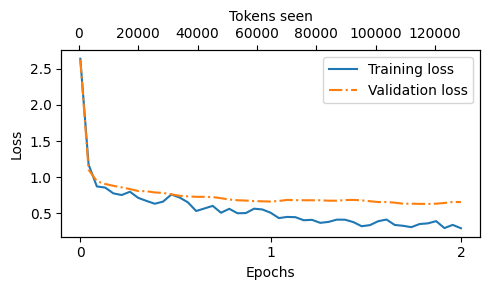

In [49]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))

prv.plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses);

In [50]:
# Saving the fine-tuned model
torch.save(model.state_dict(), "medium_fine_tuned.pth")

In [51]:
# # Saving the fine-tuned model
# torch.save({
#     'model_state': model.state_dict(),
#     'optimizer' : optimizer.state_dict()
# }, "medium_fine_tuned.pth"
# )

In [52]:
! du -Sh medium_fine_tuned.pth

1.7G	medium_fine_tuned.pth


### 7.7 Extracting and saving responses

In [55]:
from tqdm import tqdm

In [53]:
pad_token_id

[50256]

In [209]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = prv.generate(
        model=model,
        idx = prv.text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG['context_length'],
        eos_id=pad_token_id[0]
    )

    generated_text = prv.token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:","").strip()
    
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

    

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> 
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> 
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> 
-------------------------------------


In [56]:
json_file = 'my_instruction_data_w_response.json'

In [57]:
torch.manual_seed(123)

# for entry in test_data[:10]:
for entry in tqdm(test_data, total=len(test_data)):
    input_text = format_input(entry)
    token_ids = prv.generate(
        model=model,
        idx = prv.text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG['context_length'],
        eos_id=pad_token_id[0]
    )

    generated_text = prv.token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:","").strip()
    
    entry['model_response'] = response_text


with open(json_file,'w', encoding='utf-8') as f:
    json.dump(test_data, f, indent=4)
    

100%|██████████| 110/110 [01:19<00:00,  1.39it/s]


### 7.8 Evaluating the fine-tuned LLM

In [ ]:
from dotenv import load_dotenv

load_dotenv()

In [67]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [68]:
# # Load the fine-tuned parameters to the model

# file_name = "medium_fine_tuned.pth"

# model = prv.GPTModel(BASE_CONFIG)
# model.to(device)

# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

# params = torch.load(file_name, weights_only=True, map_location=device)
# model.load_state_dict(params['model_state'])

# model.eval();

*Evaluating with `Gemini3-flash` model* 

In [78]:
from google import genai
from google.genai import types

In [79]:

client = genai.Client()

In [71]:
with open(json_file,"r", encoding="utf-8") as f:
    data = json.load(f)

In [73]:
data[:3]

[{'instruction': 'Rewrite the sentence using a simile.',
  'input': 'The car is very fast.',
  'output': 'The car is as fast as lightning.',
  'model_response': 'The car is as fast as a bullet.'},
 {'instruction': 'What type of cloud is typically associated with thunderstorms?',
  'input': '',
  'output': 'The type of cloud typically associated with thunderstorms is cumulonimbus.',
  'model_response': 'The type of cloud associated with thunderstorms is a cumulus cloud.'},
 {'instruction': "Name the author of 'Pride and Prejudice'.",
  'input': '',
  'output': 'Jane Austen.',
  'model_response': "The author of 'Pride and Prejudice' is Jane Austen."}]

In [75]:
print(format_input(data[0]))

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.


In [ ]:
def make_prompt(item):
    return f"""
Given the model input. model response, and correct output:
<model_input>
`{format_input(item)}`
</model_input>

<model_response>
`{item['model_response']}`
</model_response>

<correct_output>
`{item['output']}`
</correct_output>

Score the model response in terms of matching the correct output on a scale from 0 to 100, 
where 100 is the best score.
Respond with the integer number only.
""" 

In [77]:
print(make_prompt(data[0]))


Given the model input. model response, and correct output:
<input>
`Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.`
</input>

<model_response>
`The car is as fast as a bullet.`
</model_response>

<correct_output>
`The car is as fast as lightning.`
</correct_output>

Score the model response in terms of matching the correct output on a scale from 0 to 100, 
where 100 is the best score.
Respond with the integer number only.



In [ ]:
gemini_model = "gemini-3.1-flash-lite-preview"

system_instruction=\
"""You are the main evaluation model.
 Your task is to compare a model response with the correct answer and assess the quality of the model."""

In [87]:
len(data)

110

In [88]:
scores = []
for item in tqdm(data, total=len(data)):
    prompt = make_prompt(item)
    
    response = client.models.generate_content(
        model=gemini_model,
        contents=prompt,
        config=types.GenerateContentConfig(
            system_instruction=system_instruction,
            thinking_config=types.ThinkingConfig(thinking_level="minimal")
            ),
    )
    score = response.text
    try:
        scores.append(int(score))
    except:
        print(f"Couldn't convert {score} to int.")
        print(f"Prompt:\n{prompt}")
        continue


 34%|███▎      | 37/110 [00:37<01:08,  1.07it/s]

Couldn't convert  thought
100 to int.
Prompt:

Given the model input. model response, and correct output:
<input>
`Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is the molecular formula for carbon dioxide?`
</input>

<model_response>
`The molecular formula for carbon dioxide is CO2.`
</model_response>

<correct_output>
`The molecular formula for carbon dioxide is CO2.`
</correct_output>

Score the model response in terms of matching the correct output on a scale from 0 to 100, 
where 100 is the best score.
Respond with the integer number only.



100%|██████████| 110/110 [01:56<00:00,  1.06s/it]


In [95]:
scores[:10]

[100, 20, 100, 0, 100, 0, 10, 100, 100, 0]

In [99]:
len(scores)

109

In [98]:
print(f'Average score: {sum(scores) / len(scores):.2f}')

Average score: 37.83


---